In [2]:
import numpy
import matplotlib.pyplot as plt
import scipy
import pandas
import seaborn

print("All imports OK")
print(numpy.__file__)
print(plt.__file__)

All imports OK
/home/govind/gov_semproject/GridCellsTheta/GridCellsCond/.venv/lib/python3.13/site-packages/numpy/__init__.py
/home/govind/gov_semproject/GridCellsTheta/GridCellsCond/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py


In [358]:
#input parameters

theta_status = True
g_max = 0.001
g_min = 0.0005
mod_depth = 0.05

tau_fall = 800.0 #ms
tau_rise = 400.0 #ms

dc_current = -2.7e-4

field_size = 4000 #ms
bw_field_size = 4000 #ms


In [359]:
from neuron import h
h.load_file('stdrun.hoc')
import numpy as np
import matplotlib.pyplot as plt
import stellate
import interneuron_amb
import importlib
importlib.reload(stellate)
h.celsius = 37.0
h.steps_per_ms = 40
h.dt = 0.025
h.cvode_active(0)

0.0

In [360]:
stellate_0 = stellate.Stellate(0)
interneuron_0 = interneuron_amb.Interneuron(0)

In [361]:
stell_ic_0 = h.IClamp(stellate_0.soma(0.5))
stell_ic_0.dur = 1e9

sim_dur = 10000 #in ms
num_steps = int(sim_dur/h.dt)
time_arr = np.arange(0,sim_dur,h.dt)

stell_v = h.Vector().record(stellate_0.soma(0.5)._ref_v)
stellate_gh_vec = h.Vector().record(stellate_0.soma(0.5).stellate_mech._ref_gh)
stellate_gnap_vec = h.Vector().record(stellate_0.soma(0.5).stellate_mech._ref_gna)
nc_stell = h.NetCon(stellate_0.soma(0.5)._ref_v, None, sec=stellate_0.soma)
nc_stell.threshold = 0
spike_times_stell = h.Vector()
nc_stell.record(spike_times_stell)
time = h.Vector().record(h._ref_t)



In [362]:
syn_inh = h.ExpSyn(stellate_0.soma(0.5))
syn_inh.e = -80
syn_inh.tau = 10.0


n_points = len(time_arr)

stell_ic = h.IClamp(stellate_0.soma(0.5))
stell_ic.dur = 1e9
dc_val = -2.7e-4
inhib_dc = np.full(n_points,dc_val,dtype=np.float64)
stell_dc_vec = h.Vector(inhib_dc)
stell_dc_vec.play(stell_ic._ref_amp,h.dt)

Vector[259]

In [430]:
g_max = 0.001
g_min = 0.00005
tau_fall = 900.0
tau_rise = 400.0

theta_freq = 7.2
mod_depth = 0.1
init_phase = np.random.uniform(0,2*np.pi)
print(init_phase)

idx_1 = int(2000/h.dt)
idx_2 = int(6000/h.dt)
idx_3 = int(6000/h.dt)

inhib_base = np.full(n_points,g_max)
t_phase1 = time_arr[idx_1:idx_2] - time_arr[idx_1]
inhib_base[idx_1:idx_2] = (g_max-g_min)*(np.exp(-t_phase1/tau_fall)) + g_min

inhib_base[idx_2:idx_3] = inhib_base[idx_2-1]

t_phase3 = time_arr[idx_3:] - time_arr[idx_3]
start_val = inhib_base[idx_3 - 1]
inhib_base[idx_3:] = (start_val + (g_max-start_val)*(1-np.exp(-t_phase3/tau_rise)))
#inhib_base[idx_3:] = start_val*np.exp(t_phase3/tau_rise)
#inhib_base[idx_3:] = np.full_like(inhib_base[idx_3:],1e-3)
theta_factor = 1 + (mod_depth*(np.sin(init_phase +  (2*np.pi*theta_freq*time_arr/1000.0))))

# --- Gaussian Disinhibition (Predictive Priming) ---
t_mid = 4000.0  # Center of the grid field
width = 2000.0  # Spatial/Temporal width of the field

# Gaussian disinhibition: Inhibition is highest far from the center
# and drops (disinhibits) as you approach t_mid.
dist_from_center = (time_arr - t_mid)
inhib_envelope = g_max - (g_max - g_min) * np.exp(-(dist_from_center**2) / (2 * width**2))

# Apply multiplicative theta modulation
inhib_cond_arr = inhib_envelope * theta_factor
#inhib_cond_arr = inhib_base #* theta_factor
noise = np.random.normal(loc=0.0,scale=1e-5,size=len(inhib_cond_arr))
inhib_cond_arr += noise
inhib_cond_arr = np.maximum(inhib_cond_arr,0.00001)

g_vec = h.Vector(inhib_cond_arr)
g_vec.play(syn_inh._ref_g, h.dt)
g_rec = h.Vector().record(syn_inh._ref_g)



4.065341730156321


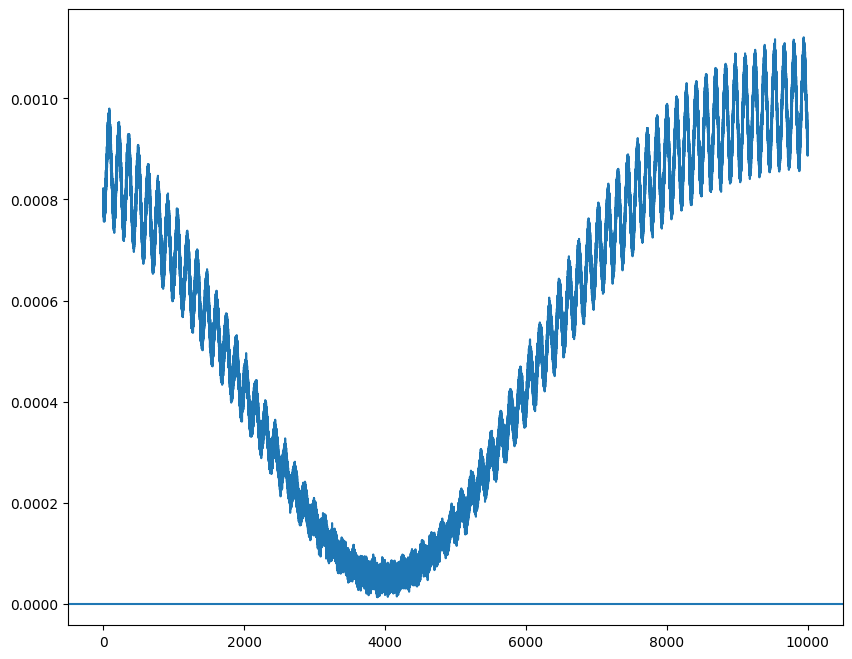

In [431]:
plt.figure(figsize=(10,8))
plt.plot(time_arr,inhib_cond_arr)
plt.axhline(y=0.0)
#plt.xlim(3800,4500)

In [432]:
h.finitialize(-80)
h.frecord_init()
h.continuerun(sim_dur)

0.0

In [433]:
#phase extraction

spikes_arr = np.array(spike_times_stell.to_python())
phases = ((init_phase+((spikes_arr) * theta_freq * 2 * np.pi / 1000)) % (2 * np.pi))
phases_shifted = phases + 2*np.pi

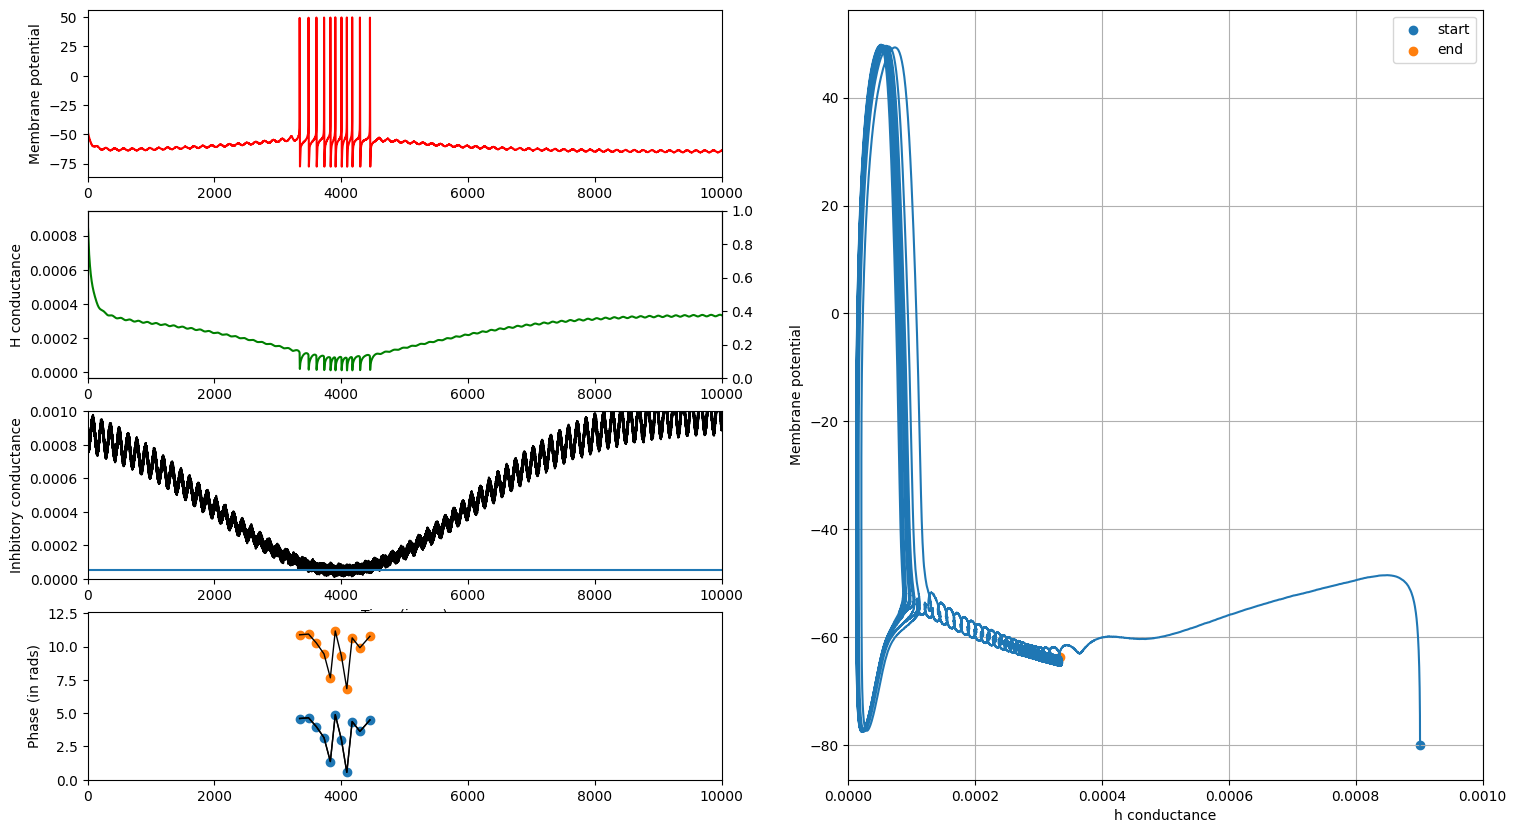

In [434]:
from matplotlib.gridspec import GridSpec

gh_cond = stellate_gh_vec.to_python()
gnap_cond = stellate_gnap_vec.to_python()
memb_pot = stell_v.to_python()
start_time = 0
end_time =  10000
start_idx = int(start_time/h.dt)
end_idx = int(end_time/h.dt)

fig = plt.figure(figsize=(18,10))

gs = GridSpec(4,2,width_ratios=[1,1])
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[1,0])
ax1_1 = ax1.twinx()
ax2 = fig.add_subplot(gs[2,0])
ax3 = fig.add_subplot(gs[3,0])

ax_phase = fig.add_subplot(gs[:,1])


ax1.plot(time_arr[start_idx:end_idx],gh_cond[start_idx:end_idx],color='green')
ax2.set_xlabel("Time (in ms)")
ax2.set_ylabel("Inhbitory conductance")
ax1.set_ylabel("H conductance")
#ax1_1.plot(time_arr[start_idx:end_idx],gnap_cond[start_idx:end_idx],color='purple')
ax0.set_ylabel("Membrane potential")
ax0.plot(time_arr[start_idx:end_idx],memb_pot[start_idx:end_idx],color='red')
ax2.plot(time_arr[start_idx:end_idx],inhib_cond_arr[start_idx:end_idx],color='black')
ax2.axhline(y=g_max)
ax3.plot(spikes_arr,phases,linewidth=1,color='black')
ax2.axhline(y=g_min)
ax3.plot(spikes_arr,phases,linewidth=1,color='black')
ax3.plot(spikes_arr,phases_shifted,linewidth=1,color='black')
ax3.scatter(spikes_arr,phases)
ax3.scatter(spikes_arr,phases_shifted)
ax3.set_ylabel("Phase (in rads)")
ax3.set_ylim(0,4*np.pi)
ax_phase.plot(gh_cond[start_idx:end_idx],memb_pot[start_idx:end_idx])
ax_phase.scatter(gh_cond[start_idx],memb_pot[start_idx],label='start')
ax_phase.scatter(gh_cond[end_idx],memb_pot[end_idx],label='end')
ax_phase.legend()
ax_phase.set_xlabel("h conductance")
ax_phase.set_ylabel("Membrane potential")
ax_phase.set_xlim(0,0.001)
ax0.set_xlim(start_time,end_time)
ax1.set_xlim(start_time,end_time)
ax2.set_xlim(start_time,end_time)
ax3.set_xlim(start_time,end_time)

theta_status = ""
ax2.set_ylim(0,0.001)
plt.suptitle(f"")
plt.grid(True)
plt.show()





In [406]:
print(phases)

[5.73952399 4.95902671 4.72931346 4.89493822 4.78460549 4.65730815
 4.54132055 4.45134534 4.36476304 4.28722854 4.23457544 4.18531527
 4.12813828 4.06417546 4.03074891 3.99392945 3.95371706 3.92594538
 3.91400733 3.89302149 3.85959494 3.84426397 3.81423035 3.81134008]


(0.0, 6.283185307179586)

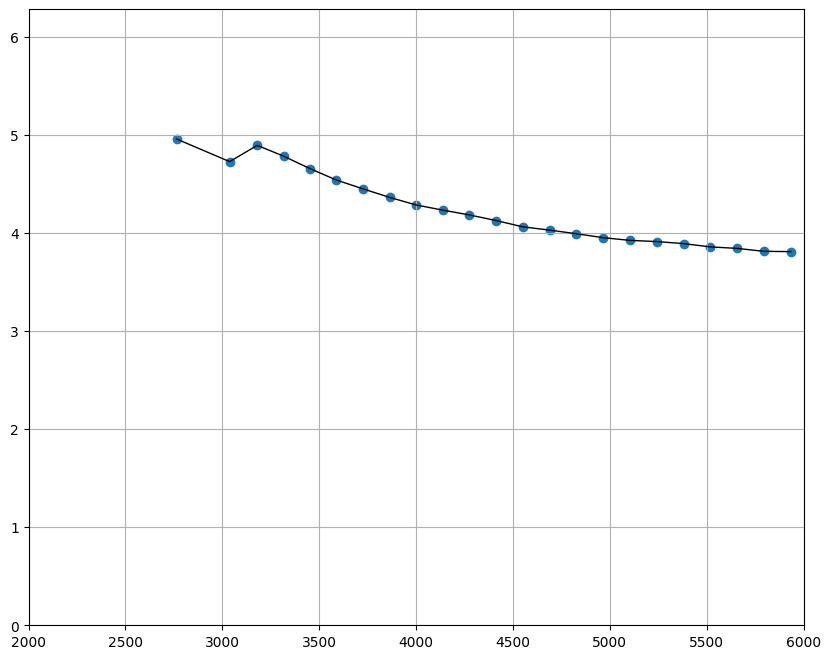

In [409]:
plt.figure(figsize=(10,8))
plt.scatter(spikes_arr,phases)
plt.plot(spikes_arr[1:],phases[1:],linewidth=1,color='black')
plt.grid(True)
plt.xlim(2000,6000)
plt.ylim(0,2*np.pi)


In [379]:
num_runs = 10
spike_times_matrix = []
spike_phases_matrix =[]

for n in range(num_runs):

    spike_times_stell.resize(0)

    curr_init_phase = np.random.uniform(0.0,2*np.pi)
    theta_factor = 1 + (mod_depth*(np.sin(curr_init_phase +  (2*np.pi*theta_freq*time_arr/1000.0))))
    inhib_cond_arr = inhib_base * theta_factor
    noise = np.random.normal(loc=0.0,scale=1e-5,size=len(inhib_cond_arr))
    inhib_cond_arr += noise
    inhib_cond_arr = np.maximum(inhib_cond_arr,0.00001)
    g_vec = h.Vector(inhib_cond_arr)
    g_vec.play(syn_inh._ref_g, h.dt)

    h.finitialize(-65)
    h.frecord_init()
    h.continuerun(sim_dur)

    temp_spikes = np.array(spike_times_stell.to_python())
    temp_phases = ((curr_init_phase+((temp_spikes) * theta_freq * 2 * np.pi / 1000)) % (2 * np.pi))

    spike_times_matrix.append(temp_spikes)
    spike_phases_matrix.append(temp_phases)

(0.0, 6.283185307179586)

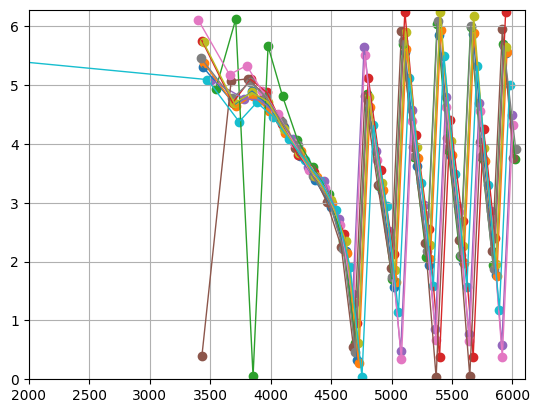

In [380]:
for times,phases in zip(spike_times_matrix,spike_phases_matrix):

    plt.scatter(times,phases)
    plt.plot(times,phases,linewidth=1)

plt.grid(True)
plt.xlim(2000,6100)
plt.ylim(0,2*np.pi)

In [335]:
import analysis_utils as a_utils
from scipy.stats import linregress

fields = a_utils.separate_fields(spike_times_matrix)
print(fields)

shifted_fields = a_utils.shift_fields_to_center(spike_times_matrix)
print(shifted_fields)

{0: [[23.27500000009921], [2802.074999994386, 3047.3749999908164, 3290.949999987272, 3421.999999985365, 3546.0749999835593, 3667.249999981796, 3790.2999999800054, 3913.124999978218, 4036.1749999764274, 4159.599999974632, 4282.849999972838, 4406.39999997104, 4530.449999969235, 4653.8499999674395, 4778.22499996563, 4902.449999963822, 5026.874999962011, 5150.724999960209, 5275.149999958398, 5400.174999956579, 5524.549999954769, 5649.0499999529575, 5773.599999951145, 5898.599999949326, 6030.124999947412]], 1: [[2756.8749999950437], [2995.2749999915745], [3235.42499998808, 3368.2999999861463, 3492.299999984342, 3613.3249999825807, 3735.0499999808094, 3857.2249999790315, 3980.474999977238, 4103.574999975447, 4226.974999973651, 4350.574999971853, 4473.849999970059, 4597.799999968255, 4722.599999966439, 4846.499999964636, 4970.899999962826, 5094.99999996102, 5219.474999959209, 5344.174999957394, 5468.17499995559, 5592.849999953775, 5717.899999951956, 5841.99999995015, 5966.899999948332]], 2: [